<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350586602" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🌲 ML 49 — Random Forest | Intuition & Code

In [1]:
import numpy as np
import pandas as pd
import random

from sklearn.tree import DecisionTreeClassifier

from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.091255,1.131631,-1.106231,1.270702,-0.265901,1
1,0.360076,-0.753756,2.045323,-1.979428,0.367651,1
2,1.483458,-1.927039,1.163021,-0.712880,-2.094741,1
3,1.013588,-3.054012,0.243180,0.022886,-3.323185,1
4,3.316970,-0.250422,1.951642,0.310860,-0.490208,1


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [8]:
df2 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df3 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col2', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [11]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [12]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.6, 0.9285714285714286, 'x[1] <= 1.163\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.4, 0.7857142857142857, 'x[1] <= -2.955\ngini = 0.42\nsamples = 30\nvalue = [9, 21]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.3, 0.6428571428571429, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5, 0.6428571428571429, 'x[1] <= 0.017\ngini = 0.375\nsamples = 28\nvalue = [7, 21]'),
 Text(0.3, 0.5, 'x[0] <= 1.166\ngini = 0.188\nsamples = 19\nvalue = [2, 17]'),
 Text(0.2, 0.35714285714285715, 'x[1] <= -1.514\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.1, 0.21428571428571427, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.3, 0.21428571428571427, 'x[1] <= -1.361\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.2, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.07142857142857142, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7, 0.5, 'x[1]

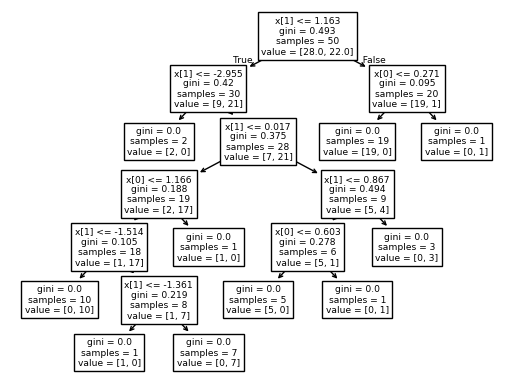

In [13]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.5833333333333334, 0.9166666666666666, 'x[1] <= 0.381\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.5, 0.75, 'x[0] <= -0.135\ngini = 0.375\nsamples = 28\nvalue = [21, 7]'),
 Text(0.5416666666666667, 0.8333333333333333, 'True  '),
 Text(0.16666666666666666, 0.5833333333333334, 'x[1] <= -2.783\ngini = 0.208\nsamples = 17\nvalue = [15, 2]'),
 Text(0.08333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.4166666666666667, 'x[1] <= -0.933\ngini = 0.117\nsamples = 16\nvalue = [15, 1]'),
 Text(0.16666666666666666, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.3333333333333333, 0.25, 'x[1] <= -0.592\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.25, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4166666666666667, 0.08333333333333333, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8333333333333334, 0.5833333333333334, 'x[1] <= -0.14\ngini = 0.496\nsamples = 11\nvalue = [6, 5]'),
 

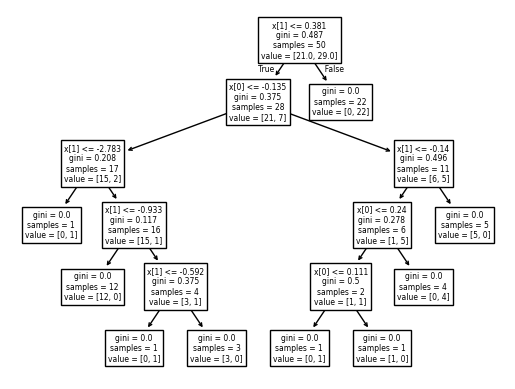

In [14]:
plot_tree(clf2)

[Text(0.4444444444444444, 0.9, 'x[0] <= 0.465\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.2222222222222222, 0.7, 'x[1] <= -1.46\ngini = 0.384\nsamples = 27\nvalue = [20, 7]'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= 1.023\ngini = 0.227\nsamples = 23\nvalue = [20, 3]'),
 Text(0.2222222222222222, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.4444444444444444, 0.3, 'x[1] <= 1.177\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5555555555555556, 0.1, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.6666666666666666, 0.7, 'x[1] <= 1.876\ngini = 0.083\nsamples = 23\nvalue = [1, 22]'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.7777777777777778, 0.5, 'x[0] <= 1.515\ngini = 0.444\ns

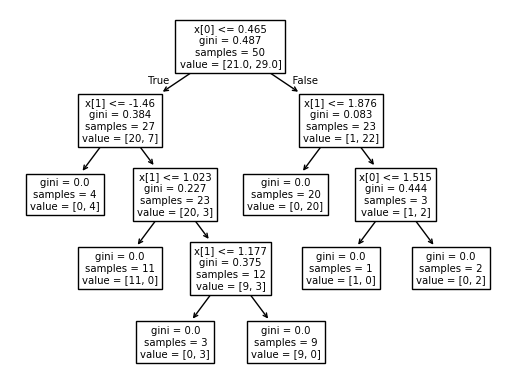

In [15]:
plot_tree(clf3)

In [16]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [17]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [18]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])